# 5) Initial Data Preprocessing & Dataset Documentation

This notebook performs initial data preprocessing and documents the characteristics of the healthcare disease prediction dataset.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)

In [35]:
url = 'https://raw.githubusercontent.com/vyasanbmathew2008/Team-6/main/healthcare-disease-prediction/dataset/healthcare_dataset.csv'

df = pd.read_csv(url)

print('Dataset loaded successfully.')

Dataset loaded successfully.


## 1. Initial Dataset Inspection

In [36]:
print('Dataset Shape:', df.shape)

print('\nColumn Names:')
print(df.columns.tolist())

print('\nFirst 5 Rows:')
display(df.head())

print('\nDataset Information:')
df.info()

Dataset Shape: (55500, 15)

Column Names:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

First 5 Rows:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object

## 2. Create Working Copy

In [37]:
cleaned_df = df.copy()

print('Working copy created.')

Working copy created.


## 3. Duplicate Records

In [38]:
duplicate_count = cleaned_df.duplicated().sum()

print('Duplicate Records:', duplicate_count)

Duplicate Records: 534


In [39]:
if duplicate_count > 0:
    cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

print('Shape after duplicate removal:', cleaned_df.shape)

Shape after duplicate removal: (54966, 15)


## 4. Missing Values

In [40]:
missing_values = cleaned_df.isnull().sum()

print('Missing Values:')
display(missing_values[missing_values > 0])

Missing Values:


,0


### Handle Missing Target Values

In [41]:
target_column = 'Medical Condition'

if cleaned_df[target_column].isnull().sum() > 0:
    cleaned_df = cleaned_df.dropna(subset=[target_column])

print('Missing target values:', cleaned_df[target_column].isnull().sum())

Missing target values: 0


### Handle Missing Numerical Values

In [42]:
numerical_columns = cleaned_df.select_dtypes(include=np.number).columns

for column in numerical_columns:
    if cleaned_df[column].isnull().sum() > 0:
        cleaned_df[column] = cleaned_df[column].fillna(cleaned_df[column].median())

print('Numerical missing values handled.')

Numerical missing values handled.


### Handle Missing Categorical Values

In [43]:
categorical_columns = cleaned_df.select_dtypes(include='object').columns

for column in categorical_columns:
    if cleaned_df[column].isnull().sum() > 0:
        cleaned_df[column] = cleaned_df[column].fillna(cleaned_df[column].mode()[0])

print('Categorical missing values handled.')

Categorical missing values handled.


In [44]:
remaining_missing = cleaned_df.isnull().sum()

print('Remaining Missing Values:')
display(remaining_missing[remaining_missing > 0])

Remaining Missing Values:


,0


## 5. Text Cleaning

In [45]:
text_columns = cleaned_df.select_dtypes(include='object').columns

for column in text_columns:
    cleaned_df[column] = cleaned_df[column].str.replace(r'\\s+', ' ', regex=True).str.strip()

print('Extra spaces removed from text columns.')

Extra spaces removed from text columns.


## 6. Standardize Patient Names

Patient names in the dataset have inconsistent capitalization. The following preprocessing standardizes the capitalization of each word without removing any words.

In [46]:
if 'Name' in cleaned_df.columns:
    cleaned_df['Name'] = (
        cleaned_df['Name']
        .str.replace(r'\\s+', ' ', regex=True)
        .str.strip()
        .apply(
            lambda name: ' '.join(word.capitalize() for word in name.split())
            if isinstance(name, str) else name
        )
    )

print('Patient names standardized successfully.')

display(cleaned_df[['Name']].head(10))

Patient names standardized successfully.


,Name
0,Bobby Jackson
1,Leslie Terry
2,Danny Smith
3,Andrew Watts
4,Adrienne Bell
5,Emily Johnson
6,Edward Edwards
7,Christina Martinez
8,Jasmine Aguilar
9,Christopher Berg


### Example

Before preprocessing:

- Bobby JacksOn
- LesLie TErRy
- DaNnY sMitH
- andrEw waTtS

After preprocessing:

- Bobby Jackson
- Leslie Terry
- Danny Smith
- Andrew Watts

## 7. Identify Date Columns

In [47]:
date_columns = [
    column for column in cleaned_df.columns
    if 'date' in column.lower()
]

print('Date Columns:')
print(date_columns)

Date Columns:
['Date of Admission', 'Discharge Date']


## 8. Convert Date Columns

In [48]:
for column in date_columns:
    cleaned_df[column] = pd.to_datetime(cleaned_df[column], errors='coerce')

print('Date columns converted to datetime format.')

Date columns converted to datetime format.


In [49]:
for column in date_columns:
    print(column, ':', cleaned_df[column].dtype)

Date of Admission : datetime64[ns]
Discharge Date : datetime64[ns]


## 9. Identify Initially Irrelevant Columns

In [50]:
columns_to_remove = [
    'Name',
    'Doctor',
    'Hospital',
    'Room Number'
]

columns_to_remove = [
    column for column in columns_to_remove
    if column in cleaned_df.columns
]

print('Columns identified for initial removal:')
print(columns_to_remove)

Columns identified for initial removal:
['Name', 'Doctor', 'Hospital', 'Room Number']


In [51]:
cleaned_df = cleaned_df.drop(columns=columns_to_remove)

print('Shape after removing initially irrelevant columns:', cleaned_df.shape)

Shape after removing initially irrelevant columns: (54966, 11)


## 10. Prediction Timing Considerations

Some variables may contain information that becomes available only after diagnosis or treatment. These variables should be evaluated carefully before final model training.

In [52]:
timing_sensitive_columns = [
    'Discharge Date',
    'Medication',
    'Test Results',
    'Billing Amount'
]

timing_sensitive_columns = [
    column for column in timing_sensitive_columns
    if column in cleaned_df.columns
]

print('Prediction-timing-sensitive columns:')
print(timing_sensitive_columns)

Prediction-timing-sensitive columns:
['Discharge Date', 'Medication', 'Test Results', 'Billing Amount']


## 11. Create Length of Stay

In [53]:
if 'Date of Admission' in cleaned_df.columns and 'Discharge Date' in cleaned_df.columns:
    cleaned_df['Length of Stay'] = (
        cleaned_df['Discharge Date'] - cleaned_df['Date of Admission']
    ).dt.days

print('Length of Stay feature created.')

Length of Stay feature created.


In [54]:
if 'Length of Stay' in cleaned_df.columns:
    display(cleaned_df['Length of Stay'].describe())

,Length of Stay
count,54966.000000
mean,15.499290
std,8.661471
min,1.000000
25%,8.000000
50%,15.000000
75%,23.000000
max,30.000000


## 12. Validate Target Variable

In [55]:
target_column = 'Medical Condition'

print('Target Variable:', target_column)

print('\nTarget Categories:')
print(cleaned_df[target_column].unique())

print('\nNumber of Target Classes:')
print(cleaned_df[target_column].nunique())

Target Variable: Medical Condition

Target Categories:
['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']

Number of Target Classes:
6


## 13. Target Distribution

In [56]:
target_distribution = cleaned_df[target_column].value_counts()

print('Target Distribution:')
display(target_distribution)

Target Distribution:


,count
Medical Condition,
Arthritis,9218
Diabetes,9216
Hypertension,9151
Obesity,9146
Cancer,9140
Asthma,9095


In [57]:
target_percentage = (
    cleaned_df[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print('Target Distribution (%):')
display(target_percentage)

Target Distribution (%):


,proportion
Medical Condition,
Arthritis,16.77
Diabetes,16.77
Hypertension,16.65
Obesity,16.64
Cancer,16.63
Asthma,16.55


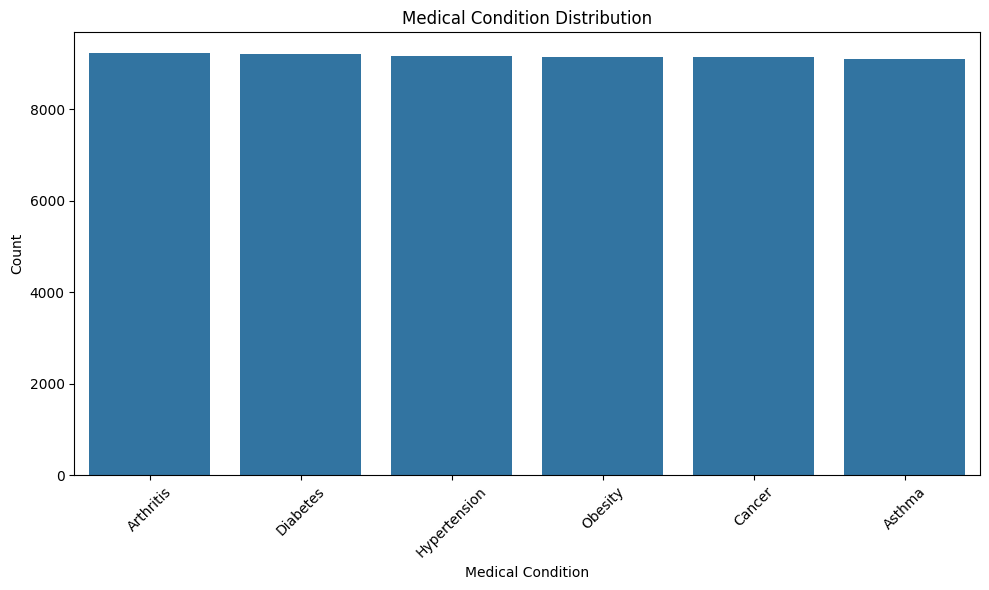

In [58]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=cleaned_df,
    x=target_column,
    order=cleaned_df[target_column].value_counts().index
)

plt.title('Medical Condition Distribution')
plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Final Data Quality Checks

In [59]:
print('Final Duplicate Records:', cleaned_df.duplicated().sum())

final_missing = cleaned_df.isnull().sum()

print('\nFinal Missing Values:')
display(final_missing[final_missing > 0])

print('\nFinal Dataset Shape:', cleaned_df.shape)

Final Duplicate Records: 0

Final Missing Values:


,0



Final Dataset Shape: (54966, 12)


In [60]:
print('Final Dataset Information:')
cleaned_df.info()

Final Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Age                 54966 non-null  int64         
 1   Gender              54966 non-null  object        
 2   Blood Type          54966 non-null  object        
 3   Medical Condition   54966 non-null  object        
 4   Date of Admission   54966 non-null  datetime64[ns]
 5   Insurance Provider  54966 non-null  object        
 6   Billing Amount      54966 non-null  float64       
 7   Admission Type      54966 non-null  object        
 8   Discharge Date      54966 non-null  datetime64[ns]
 9   Medication          54966 non-null  object        
 10  Test Results        54966 non-null  object        
 11  Length of Stay      54966 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(7)
memory usage: 5.0+ MB

In [61]:
print('First 5 Rows of Preprocessed Dataset:')
display(cleaned_df.head())

First 5 Rows of Preprocessed Dataset:


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,30,Male,B-,Cancer,2024-01-31,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal,2
1,62,Male,A+,Obesity,2019-08-20,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,2022-09-22,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal,15
3,28,Female,O+,Diabetes,2020-11-18,Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,2022-09-19,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,20


## 15. Dataset Characteristics

In [62]:
print('Number of Rows:', cleaned_df.shape[0])
print('Number of Columns:', cleaned_df.shape[1])

print('\nNumerical Columns:')
print(cleaned_df.select_dtypes(include=np.number).columns.tolist())

print('\nCategorical Columns:')
print(cleaned_df.select_dtypes(include='object').columns.tolist())

print('\nDate Columns:')
print(cleaned_df.select_dtypes(include='datetime').columns.tolist())

Number of Rows: 54966
Number of Columns: 12

Numerical Columns:
['Age', 'Billing Amount', 'Length of Stay']

Categorical Columns:
['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']

Date Columns:
['Date of Admission', 'Discharge Date']


In [63]:
column_summary = pd.DataFrame({
    'Column': cleaned_df.columns,
    'Data Type': cleaned_df.dtypes.astype(str),
    'Unique Values': cleaned_df.nunique(),
    'Missing Values': cleaned_df.isnull().sum()
})

display(column_summary)

,Column,Data Type,Unique Values,Missing Values
Age,Age,int64,77,0
Gender,Gender,object,2,0
Blood Type,Blood Type,object,8,0
Medical Condition,Medical Condition,object,6,0
Date of Admission,Date of Admission,datetime64[ns],1827,0
Insurance Provider,Insurance Provider,object,5,0
Billing Amount,Billing Amount,float64,50000,0
Admission Type,Admission Type,object,3,0
Discharge Date,Discharge Date,datetime64[ns],1856,0
Medication,Medication,object,5,0


## 16. Preprocessing Summary

In [64]:
print('Initial preprocessing completed.')

print('\nSummary:')
print('- Duplicate records checked and removed.')
print('- Missing target values handled.')
print('- Numerical missing values handled using median.')
print('- Categorical missing values handled using mode.')
print('- Text whitespace standardized.')
print('- Patient name capitalization standardized before removal.')
print('- Date columns converted to datetime.')
print('- Initially irrelevant columns removed.')
print('- Prediction-timing-sensitive variables identified.')
print('- Length of Stay feature created.')
print('- Target variable validated.')

Initial preprocessing completed.

Summary:
- Duplicate records checked and removed.
- Missing target values handled.
- Numerical missing values handled using median.
- Categorical missing values handled using mode.
- Text whitespace standardized.
- Patient name capitalization standardized before removal.
- Date columns converted to datetime.
- Initially irrelevant columns removed.
- Prediction-timing-sensitive variables identified.
- Length of Stay feature created.
- Target variable validated.


## 17. Create Runtime Directory and Save Initial Preprocessed Data

A dedicated runtime directory is created in the Colab environment to store the initially preprocessed dataset.

In [65]:
# Create a dedicated directory for runtime-generated files
runtime_dir = '/content/healthcare_runtime'
os.makedirs(runtime_dir, exist_ok=True)

# Save the initial preprocessed dataset
output_path = os.path.join(runtime_dir, 'cleaned_data.csv')

cleaned_df.to_csv(output_path, index=False)

print(f'Runtime directory created: {runtime_dir}')
print(f'Initial preprocessed dataset saved to: {output_path}')

Runtime directory created: /content/healthcare_runtime
Initial preprocessed dataset saved to: /content/healthcare_runtime/cleaned_data.csv


## 18. Verify Saved Preprocessed Data

In [66]:
print('Runtime directory:', runtime_dir)
print('File exists:', os.path.exists(output_path))

preprocessed_df = pd.read_csv(output_path)

print('Saved Dataset Shape:', preprocessed_df.shape)

print('\nSaved Dataset Columns:')
print(preprocessed_df.columns.tolist())

print('\nFirst 5 Rows:')
display(preprocessed_df.head())

Runtime directory: /content/healthcare_runtime
File exists: True
Saved Dataset Shape: (54966, 12)

Saved Dataset Columns:
['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Insurance Provider', 'Billing Amount', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Length of Stay']

First 5 Rows:


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,30,Male,B-,Cancer,2024-01-31,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal,2
1,62,Male,A+,Obesity,2019-08-20,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,2022-09-22,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal,15
3,28,Female,O+,Diabetes,2020-11-18,Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,2022-09-19,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,20


## 19. Conclusion

The dataset was initially preprocessed by removing duplicate records, handling missing values, standardizing text fields and patient names, converting date columns, removing initially irrelevant columns, and creating the Length of Stay feature.

The target variable, Medical Condition, was validated and its class distribution was examined.

The resulting initially preprocessed dataset was saved as `preprocessed_data.csv` inside the `healthcare_runtime` directory in the Colab runtime.